# Lotka Volterra (4 parameters) test case  

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from data_collection import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



True

In [2]:
# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

In [3]:
import itertools

# Define the intervals and number of points
num_points = 5  # Number of points in each linspace (adjust as needed)
# first_interval = np.linspace(2, 3.2, num_points)
# second_interval = np.linspace(0.6, 1.9, num_points)
# third_interval = np.linspace(0.6, 1.9, num_points)
# fourth_interval = np.linspace(0.8, 2.1, num_points)
first_interval = np.linspace(2.1, 3, num_points)
second_interval = np.linspace(0.9, 1.5, num_points)
third_interval = np.linspace(0.9, 1.5, num_points)
fourth_interval = np.linspace(1., 2.1, num_points)
# Generate all combinations using itertools.product
combinations = list(itertools.product(first_interval, second_interval, third_interval, fourth_interval))

# Convert the combinations to a numpy array
combinations_array = np.array(combinations)

# Shuffle the rows of the array
np.random.shuffle(combinations_array)

print(combinations_array)

[[3.    1.2   1.05  1.55 ]
 [3.    0.9   0.9   1.   ]
 [2.775 1.05  1.05  1.55 ]
 ...
 [3.    1.05  0.9   1.55 ]
 [2.325 0.9   0.9   1.   ]
 [2.55  0.9   1.35  1.   ]]


In [4]:
# reproducibility
seed = 7
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

In [5]:
solver_HF = System2()
solver_LF = System2()

num_params=4
params=combinations_array[0:10,:]

(t_HF,y_HF,mu_HF)=solver_HF.generate_dataset(T=5.0, params=params, h=0.01, fidelity='HF')
solver_HF.save_dataset('dataset_HF_4params.h5')

(t_LF,y_LF,mu_LF)=solver_LF.generate_dataset(T=5.0, params=params, h=0.04, fidelity='LF')   #0.04
solver_LF.save_dataset('dataset_LF_4params.h5')


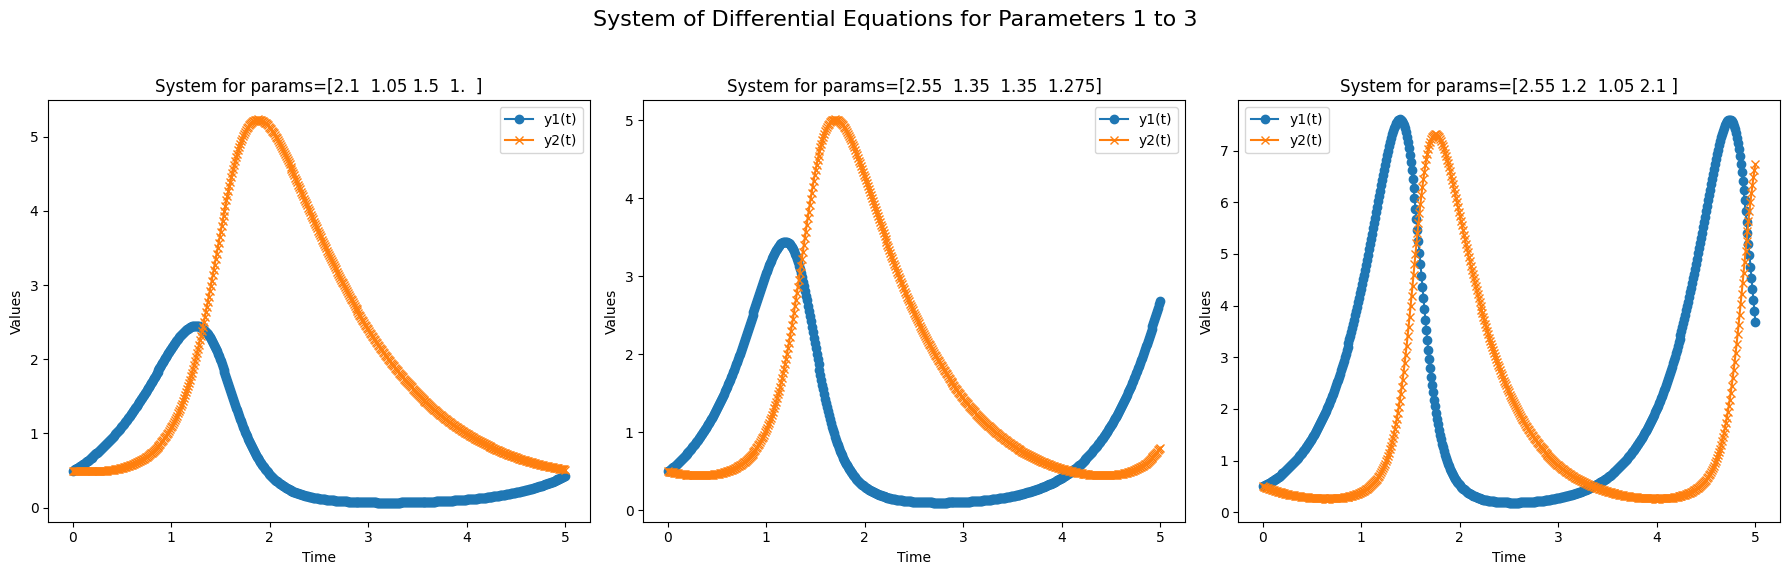

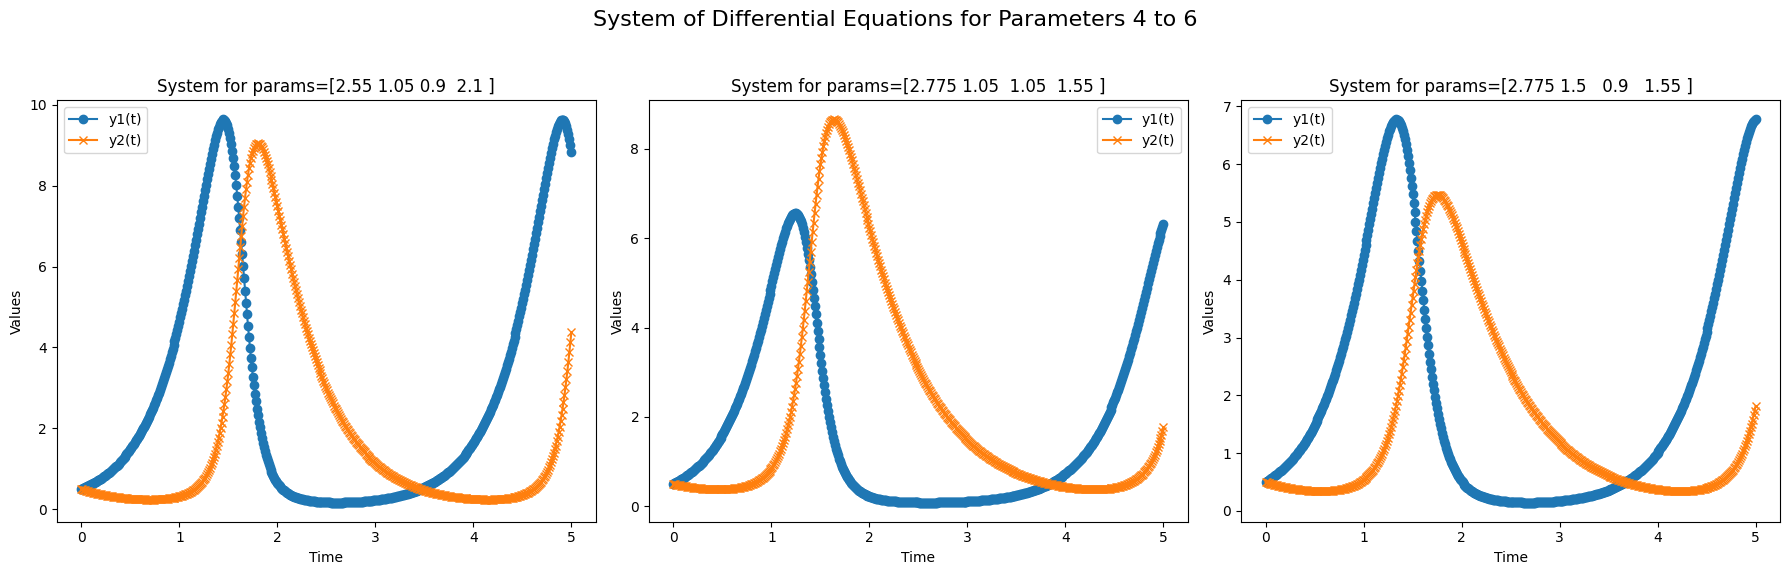

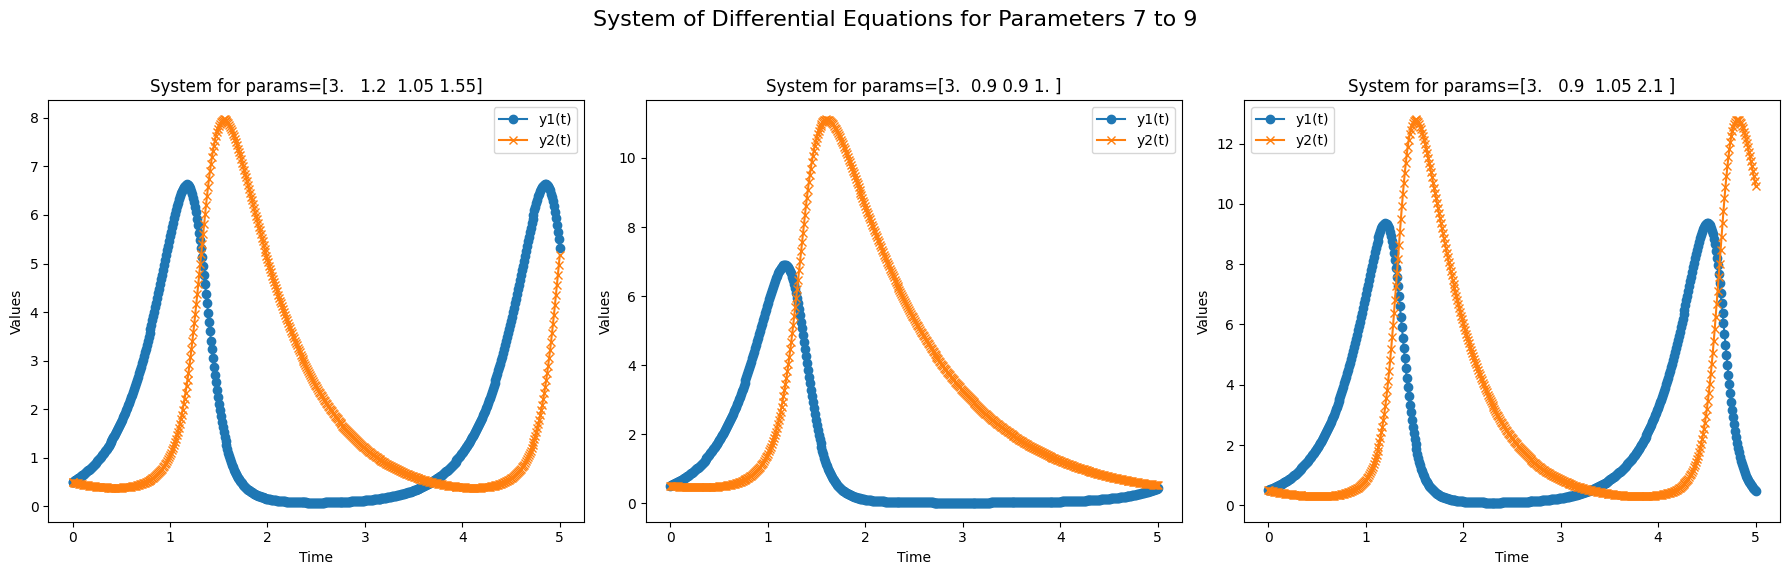

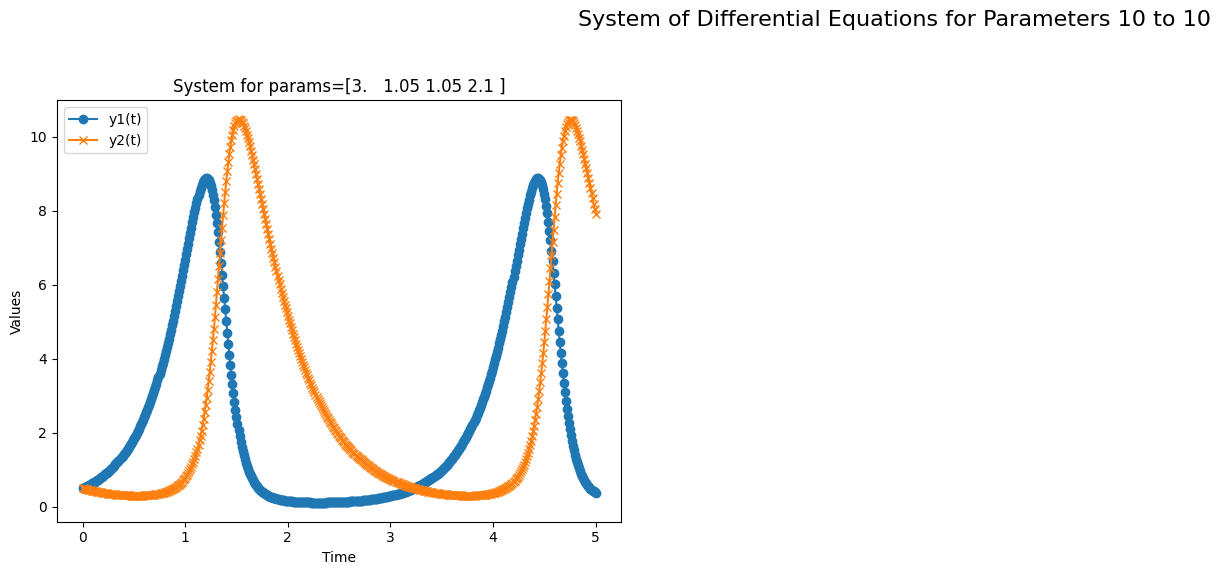

In [6]:
solver_HF.plot_results()

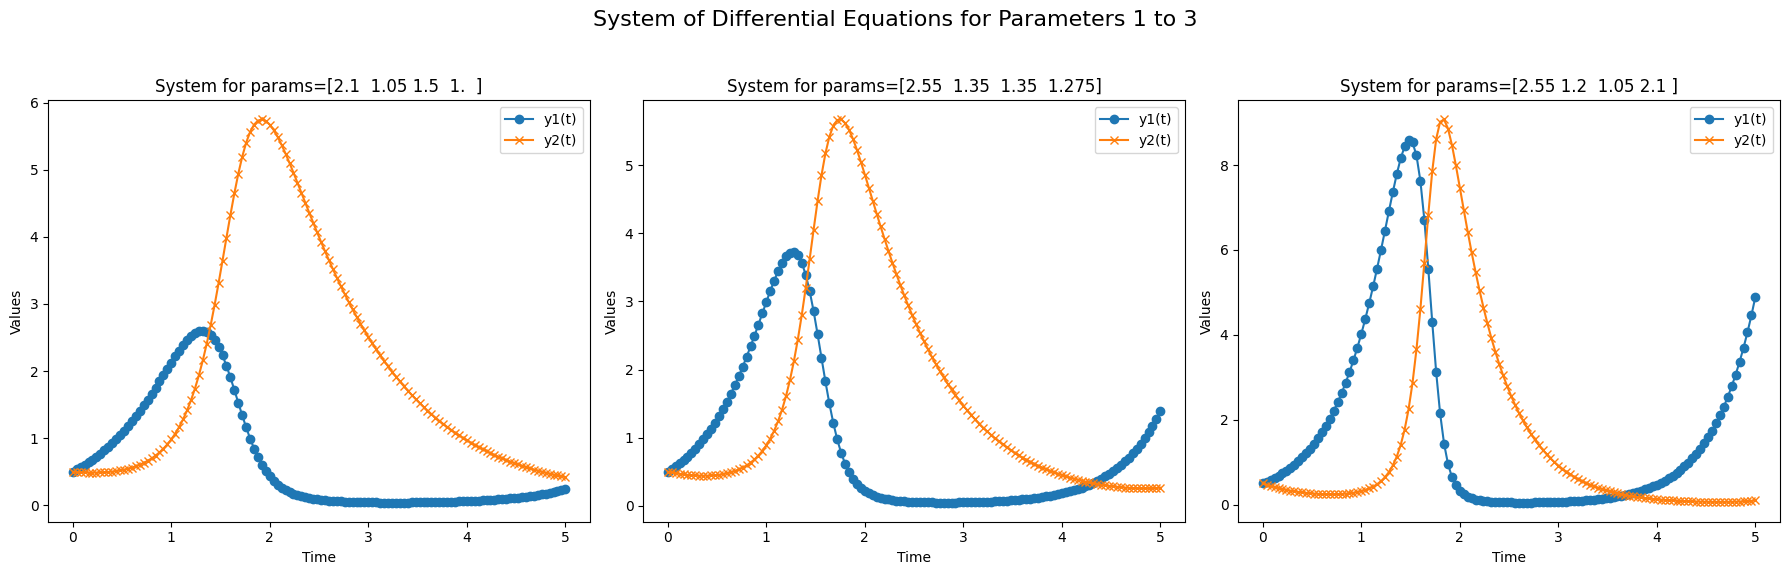

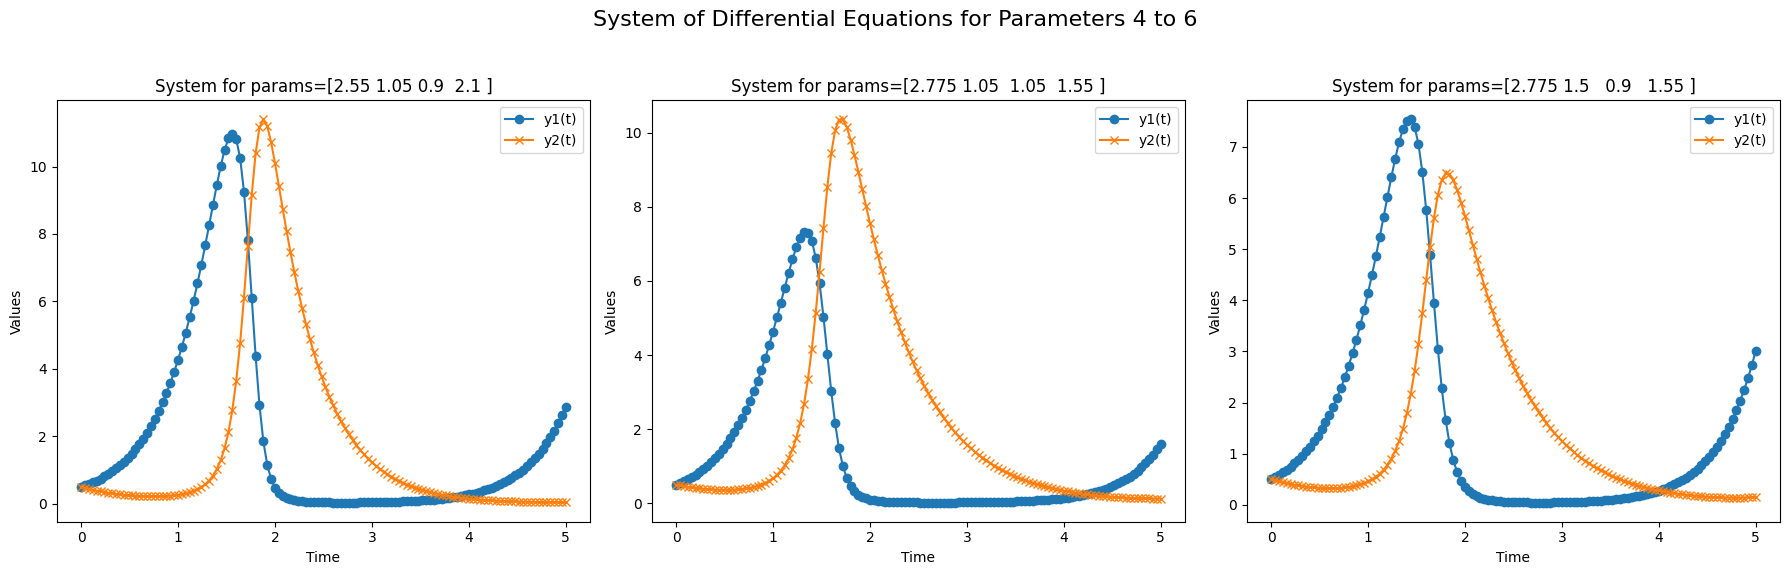

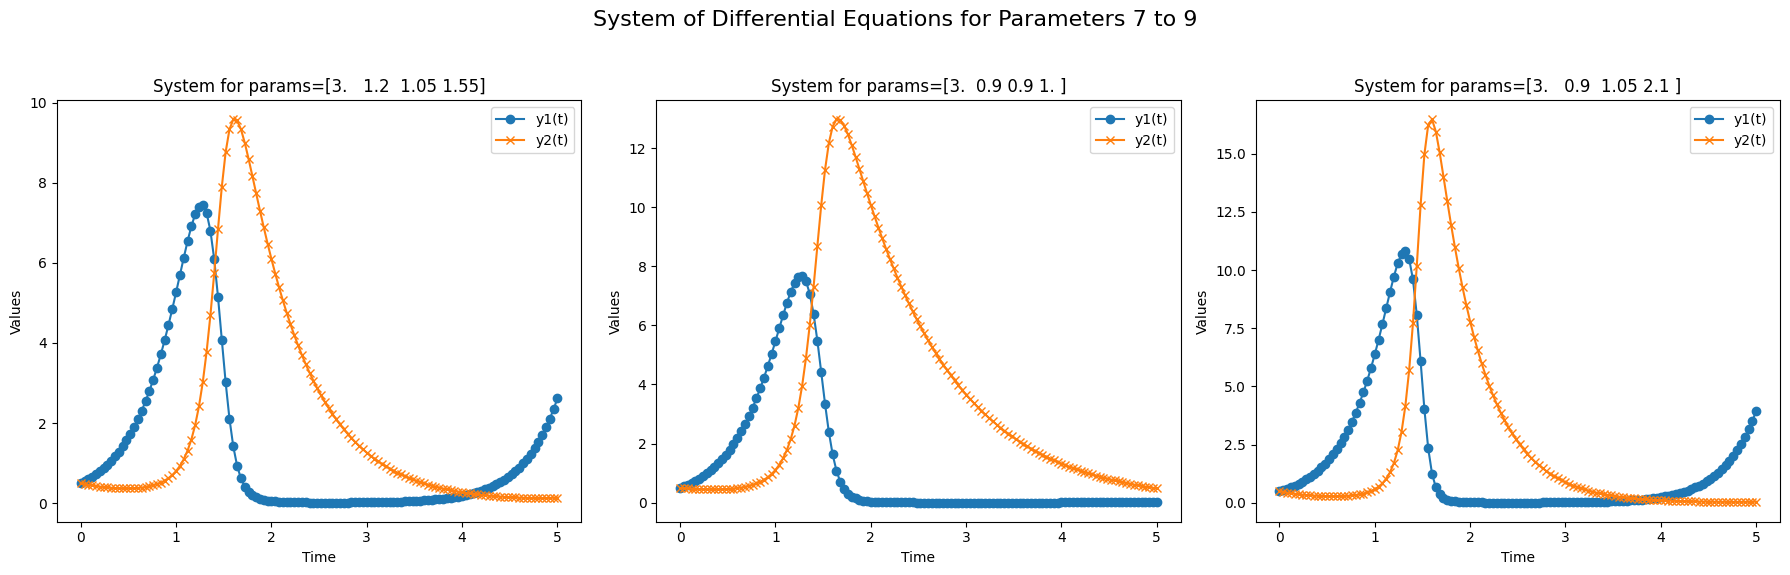

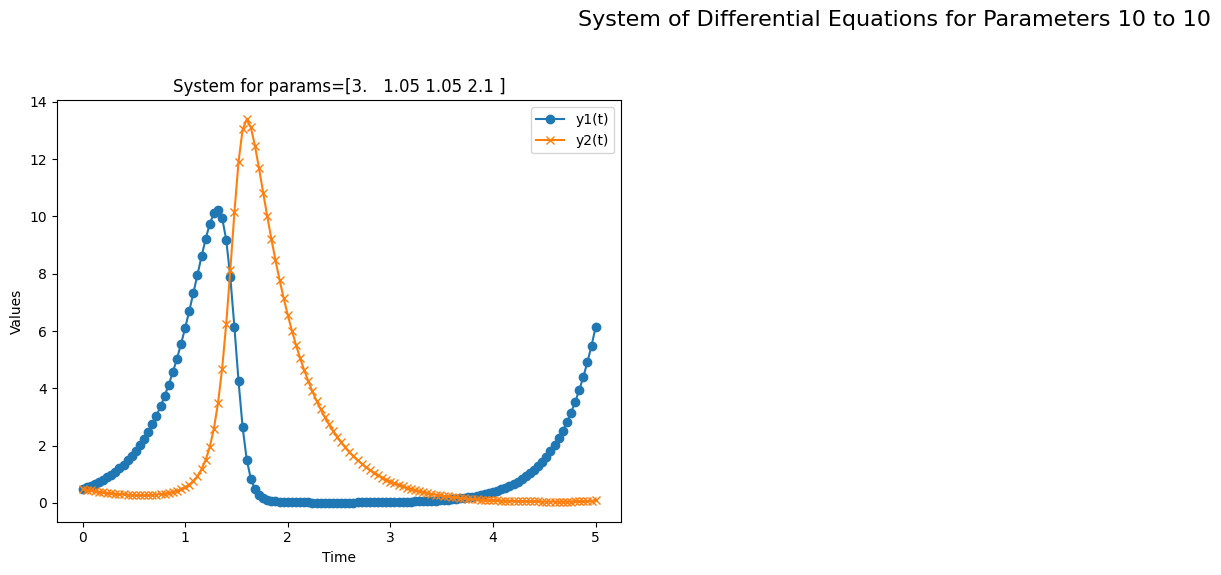

In [7]:
solver_LF.plot_results()

In [8]:
# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_HF.shape[0]), np.arange(t_HF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_HF = np.hstack((t_HF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_HF[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_LF.shape[0]), np.arange(t_LF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_LF = np.hstack((t_LF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_LF[cartesian_product_indices[:, 0]]))


In [50]:
x_LF.shape

(1260, 5)

In [9]:
y_HF=np.array(y_HF).reshape(-1, solver_HF.get_dim())
y_LF=np.array(y_LF).reshape(-1, solver_LF.get_dim())

In [52]:
y_HF.shape

(5010, 2)

The function training took 258.886216 seconds.


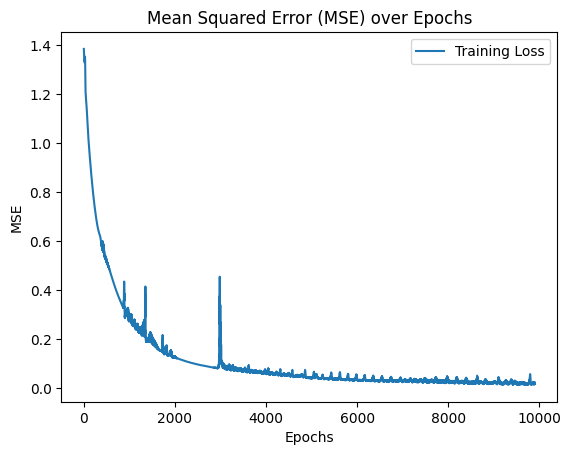

Test MSE: 1.3911217507300704
R^2: 0.685894212761045


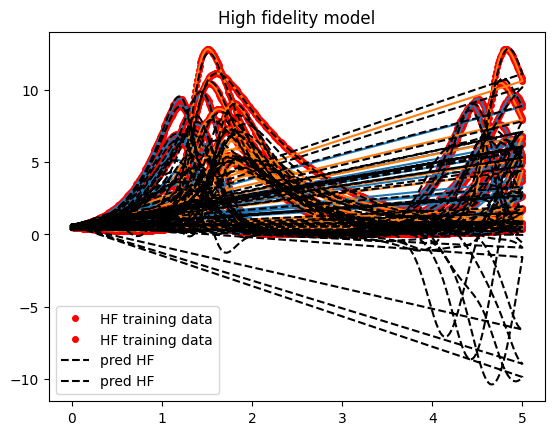

In [16]:
N=10000
n=1000
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
definition_HF = {
    "network_type": "LF",
    "params": bestLF_params,
    "data_train": x_HF,
    "output_train": y_HF,
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}
HF_model = NetworkFactory.build_network(**definition_HF)


solver_test=System2()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=5.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=HF_model.prediction(datatest)

(mse_MF,R_MF)=HF_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 2))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

The function training took 227.284306 seconds.


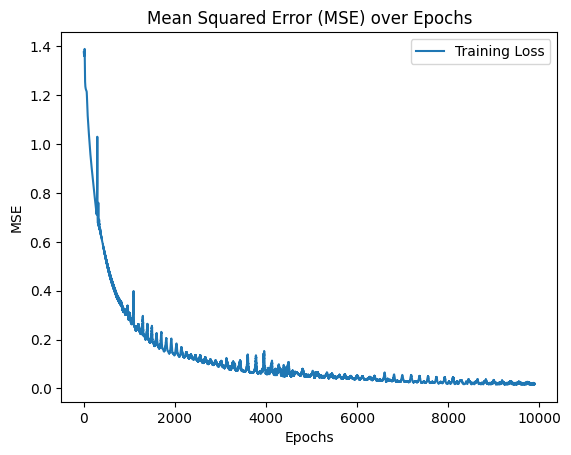

Test MSE: 1.6399942364403908
R^2: 0.6297005057723286


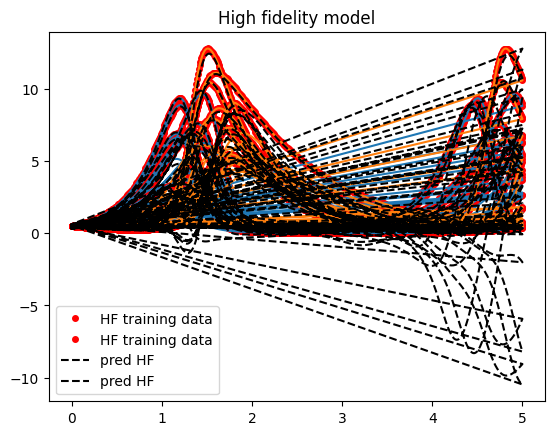

In [58]:
N=10000
n=1000
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
definition_HF = {
    "network_type": "LF",
    "params": bestLF_params,
    "data_train": x_HF,
    "output_train": y_HF,
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}
HF_model = NetworkFactory.build_network(**definition_HF)


solver_test=System2()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=5.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=HF_model.prediction(datatest)

(mse_MF,R_MF)=HF_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 2))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

In [23]:
x_HF.shape

(5010, 5)

HPO name: LF


[I 2024-08-17 02:43:04,955] A new study created in RDB with name: no-name-abce7fd2-4d66-4013-b292-660b3859293e
[I 2024-08-17 02:44:04,361] Trial 0 finished with value: 0.11034450745466498 and parameters: {'nodes': 9, 'l2weight': 0.002462440446280432, 'lr': 0.008939847496701335, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 0.11034450745466498.
[I 2024-08-17 02:44:05,100] Trial 2 finished with value: 0.2762272618365641 and parameters: {'nodes': 14, 'l2weight': 0.0002853952265545493, 'lr': 0.002611082816563654, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 0.11034450745466498.
[I 2024-08-17 02:44:05,106] Trial 6 finished with value: 0.20184535075478735 and parameters: {'nodes': 8, 'l2weight': 0.050614302334854054, 'lr': 0.01296989231693352, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 0.11034450745466498.
[I 2024-08-17 02:44:05,732] Trial 7 finished with value: 0.08668465421006265 and parameters: {'node

New parameters identified during HPO:
{'kernel_init': 'glorot_uniform',
 'l2weight': 0.039103546824625066,
 'lr': 0.004889334690262715,
 'nodes': 5,
 'opt': 'Adamax'}
The function training took 17.367530 seconds.


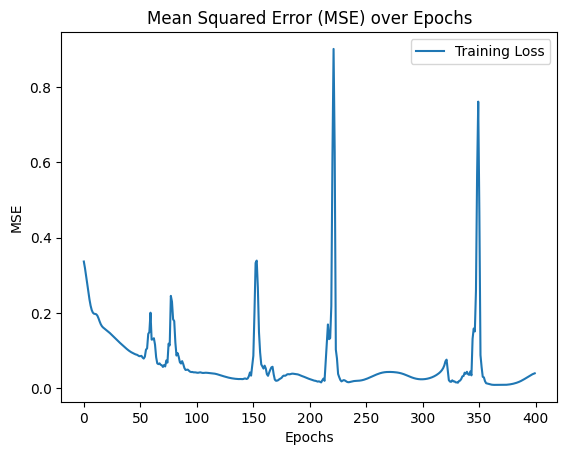

[I 2024-08-17 02:46:48,043] A new study created in RDB with name: no-name-63939163-b2d8-4a73-bac7-cd73d82e0622


HPO name: HF


[I 2024-08-17 02:48:02,155] Trial 3 finished with value: 2.2316704506817686 and parameters: {'nodes': 33, 'l2weight': 0.03841376814056507, 'lr': 0.0001440706902781464, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 3 with value: 2.2316704506817686.
[I 2024-08-17 02:48:03,757] Trial 4 finished with value: 1.9344261583518407 and parameters: {'nodes': 8, 'l2weight': 0.00024267225795578912, 'lr': 0.0008396467311103885, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 4 with value: 1.9344261583518407.
[I 2024-08-17 02:48:04,368] Trial 8 finished with value: 3.4246495803920487 and parameters: {'nodes': 7, 'l2weight': 0.00016424676263190608, 'lr': 0.00038444247547411963, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 7 with value: 0.1243963142350619.
[I 2024-08-17 02:48:04,467] Trial 7 finished with value: 0.1243963142350619 and parameters: {'nodes': 37, 'l2weight': 0.0003861425320635741, 'lr': 0.09713352844301502, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. 

New parameters identified during HPO:
{'kernel_init': 'glorot_uniform',
 'l2weight': 0.0003861425320635741,
 'lr': 0.09713352844301502,
 'nodes': 37,
 'opt': 'Adam'}
The function training took 29.294170 seconds.


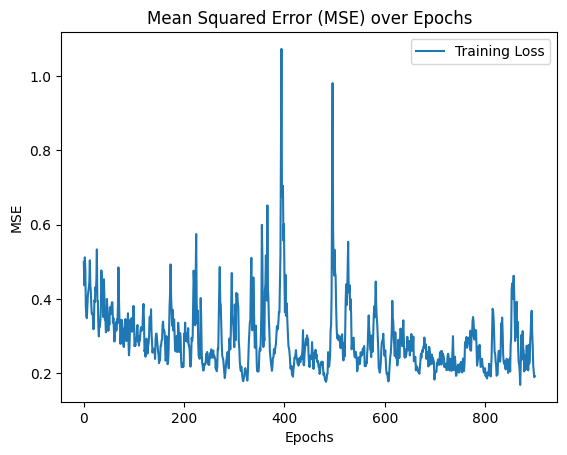

Test MSE: 0.1899452375244542
R^2: 0.9571116630635685


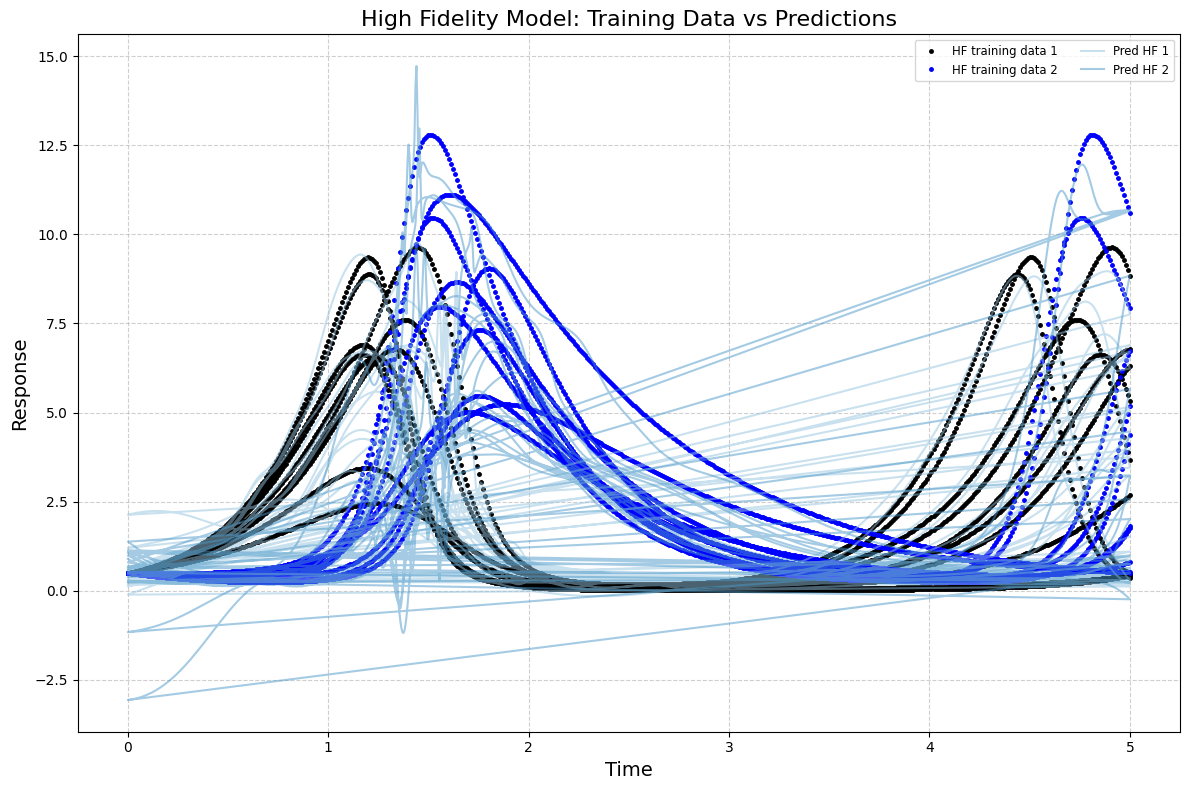

In [10]:
n_LF=500
indices_LF = np.random.permutation(x_LF.shape[0])[:n_LF]

n_HF=1000
indices_HF = np.random.permutation(x_HF.shape[0])[:n_HF]

N=[500,1000]
#n=[500,1000]
n=[50,100]

names = ['LF', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF[indices_LF,:],x_HF[indices_HF,:]],
    "output_train": [y_LF[indices_LF,:], y_HF[indices_HF,:]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": True,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System2()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=5.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


plt.figure(figsize=(12, 8))

# Plotting the training data with darker markers
plt.plot(x_HF[:, 0], y_HF[:, 0], 'k.', label='HF training data 1', markersize=5)  # Nero
plt.plot(x_HF[:, 0], y_HF[:, 1], 'b.', label='HF training data 2', markersize=5)  # Blu scuro

# Plotting the prediction data with lighter, less fluorescent colors
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '-', 
             color=plt.cm.Blues(0.4 + 0.4 * i / y_test_pred.shape[1]),  # Gamma di blu meno vividi
             alpha=0.5, label=f'Pred HF {i+1}', linewidth=1.5)  # Trasparenza ridotta e linee più sottili

# Adding grid to the plot
plt.grid(True, linestyle='--', alpha=0.6)

# Adding labels to the axes
plt.xlabel('Time', fontsize=14)
plt.ylabel('Response', fontsize=14)

# Enhancing the title
plt.title('High Fidelity Model: Training Data vs Predictions', fontsize=16)

# Improving the legend
plt.legend(loc='best', fontsize='small', ncol=2)

# Adjusting the layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
components = ['Component 1', 'Component 2', 'Component 3']
colors_training = ['k', 'b', 'g']  # Nero, Blu scuro, Verde scuro
colors_pred = ['r', 'orange', 'purple']  # Rosso, Arancione, Viola

plt.figure(figsize=(18, 6))

# Loop through each component to create a separate plot
for i in range(3):
    plt.subplot(1, 3, i + 1)  # Create a subplot (1 row, 3 columns)
    
    # Plotting the training data for the i-th component
    plt.plot(x_HF[:, 0], y_HF[:, i], f'{colors_training[i]}.', label=f'HF training data {i + 1}', markersize=7)

    # Plotting the prediction data for the i-th component
    plt.plot(datatest[:, 0], y_test_pred[:, i], '.', 
             color=colors_pred[i], alpha=0.3, label=f'Pred HF {i + 1}', linewidth=3)
    
    # Adding grid, labels, and title
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Response', fontsize=12)
    plt.title(f'High Fidelity Model: {components[i]}', fontsize=14)
    
    # Add a legend
    plt.legend(loc='best', fontsize='small')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

The function training took 23.709567 seconds.


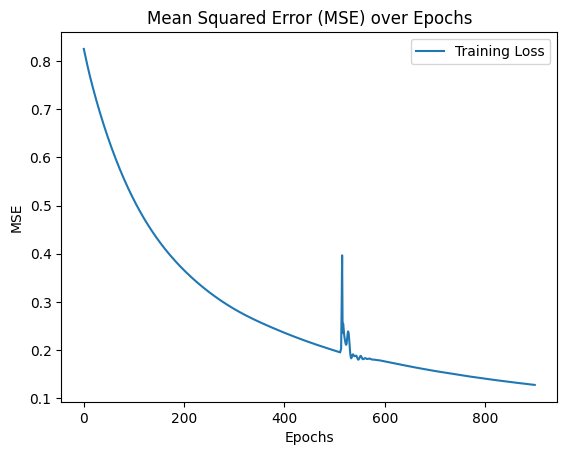

The function training took 238.881864 seconds.


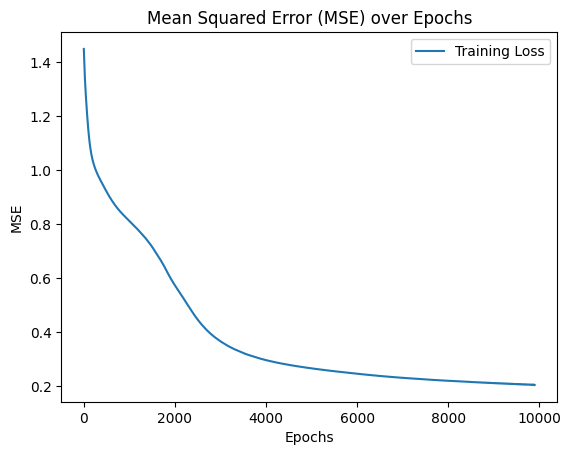

Test MSE: 0.3664788707591821
R^2: 0.9172515747483324


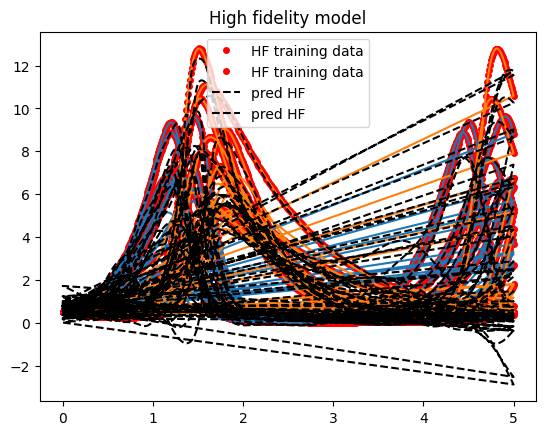

In [17]:
N=[1000,10000]
n=[500,1000]
names = ['LF', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF,x_HF],
    "output_train": [y_LF, y_HF],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System2()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=5.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 2))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

# Plotting the training data with smaller markers
plt.plot(x_HF[:, 0], y_HF[:,0], 'r.', label='HF training data', markersize=3)
plt.plot(x_HF[:, 0], y_HF[:,1], 'b.', label='HF training data', markersize=3)

# Plotting the prediction data with transparency and a colormap
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '.', color=plt.cm.viridis(i/y_test_pred.shape[1]), alpha=0.7, label=f'pred HF {i+1}', markersize=3)

# Adding legend and title
plt.legend(loc='best', fontsize='small')
plt.title('High fidelity model')

# Show the plot
plt.show()

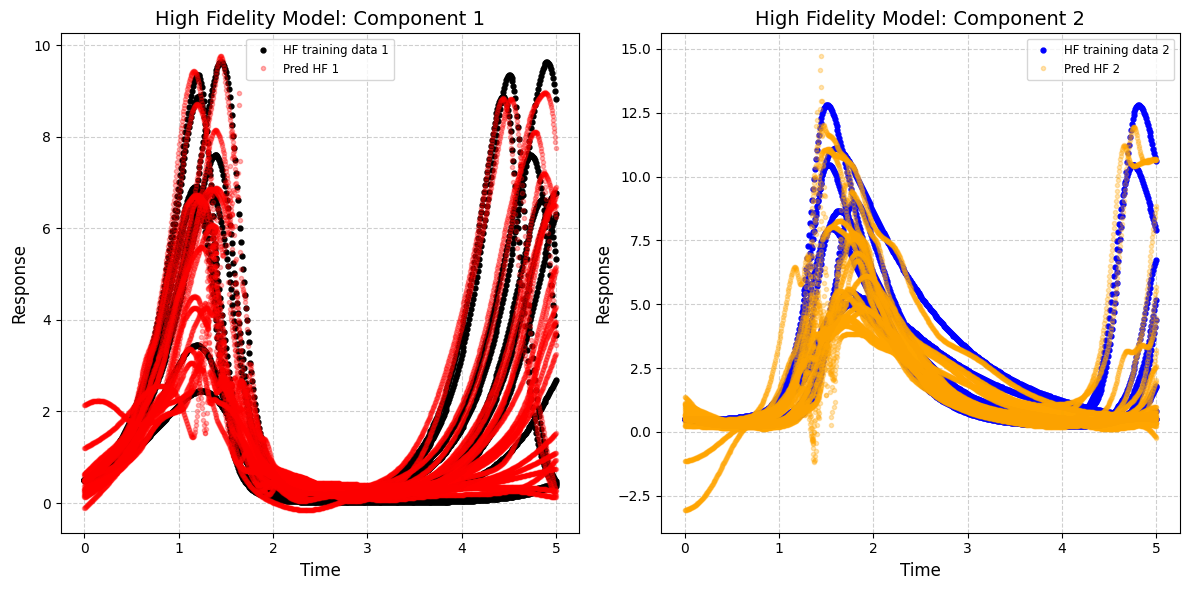

In [11]:
components = ['Component 1', 'Component 2']
colors_training = ['k', 'b']  # Nero, Blu scuro
colors_pred = ['r', 'orange']  # Rosso, Arancione

plt.figure(figsize=(18, 6))

# Loop through each component to create a separate plot
for i in range(2):
    plt.subplot(1, 3, i + 1)  # Create a subplot (1 row, 3 columns)
    
    # Plotting the training data for the i-th component
    plt.plot(x_HF[:, 0], y_HF[:, i], f'{colors_training[i]}.', label=f'HF training data {i + 1}', markersize=7)

    # Plotting the prediction data for the i-th component
    plt.plot(datatest[:, 0], y_test_pred[:, i], '.', 
             color=colors_pred[i], alpha=0.3, label=f'Pred HF {i + 1}', linewidth=3)
    
    # Adding grid, labels, and title
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Response', fontsize=12)
    plt.title(f'High Fidelity Model: {components[i]}', fontsize=14)
    
    # Add a legend
    plt.legend(loc='best', fontsize='small')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

The function training took 19.581826 seconds.


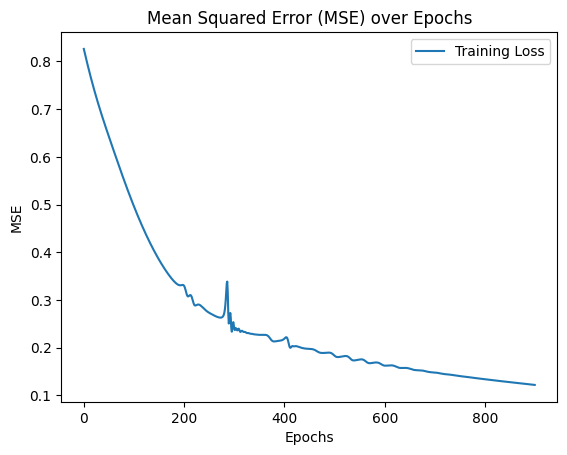

The function training took 232.610837 seconds.


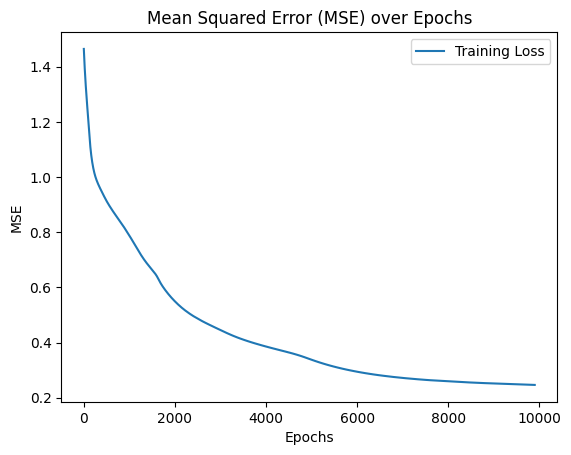

Test MSE: 0.855439301968483
R^2: 0.8068476499350703


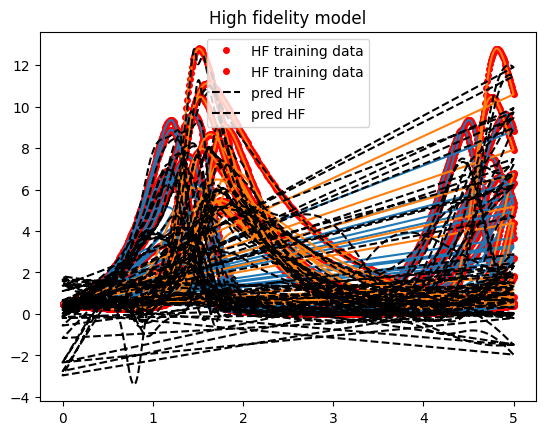

In [53]:
N=[1000,10000]
n=[500,1000]
names = ['LF', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF,x_HF],
    "output_train": [y_LF, y_HF],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System2()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=5.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 2))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

The function training took 1.994957 seconds.


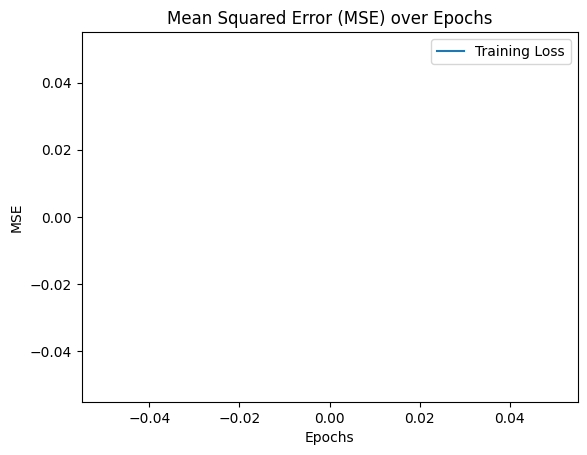

The function training took 31.436821 seconds.


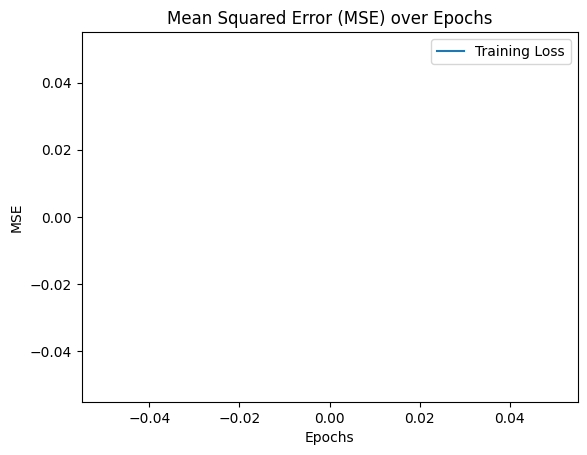

Test MSE: 1.0980160584027174
R^2: 0.7520754756047789


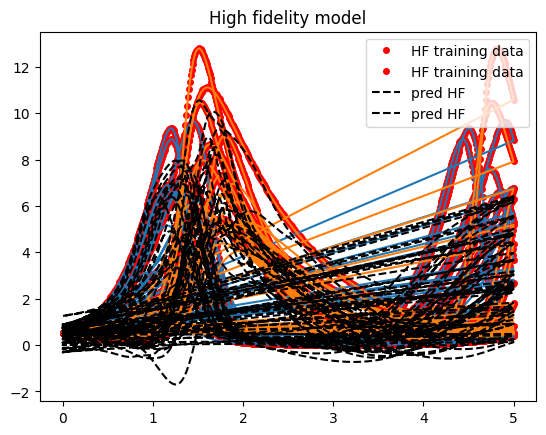

In [18]:
N=[10,100]
n=[5,10]
names = ['LF', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF,x_HF],
    "output_train": [y_LF, y_HF],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System2()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=5.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 2))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

Sampling 2 chains in parallel


2024-08-11 01:14:00,585	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\s

Estimated values are [2.508 0.9   0.523 0.854]
     mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
x0  2.508  0.0   2.508    2.508        0.0      0.0      20.0      20.0    NaN
x1  0.900  0.0   0.900    0.900        0.0      0.0      20.0      20.0    NaN
x2  0.523  0.0   0.523    0.523        0.0      0.0      20.0      20.0    NaN
x3  0.854  0.0   0.854    0.854        0.0      0.0      20.0      20.0    NaN
----  Autocorrelation  ----
----  Effective Sample Size  ----
----  Effective Sample Size per iteration  ----
----  Rank Plots  ----


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


The difference between estimated values [0.492 0.3   0.827 0.971]



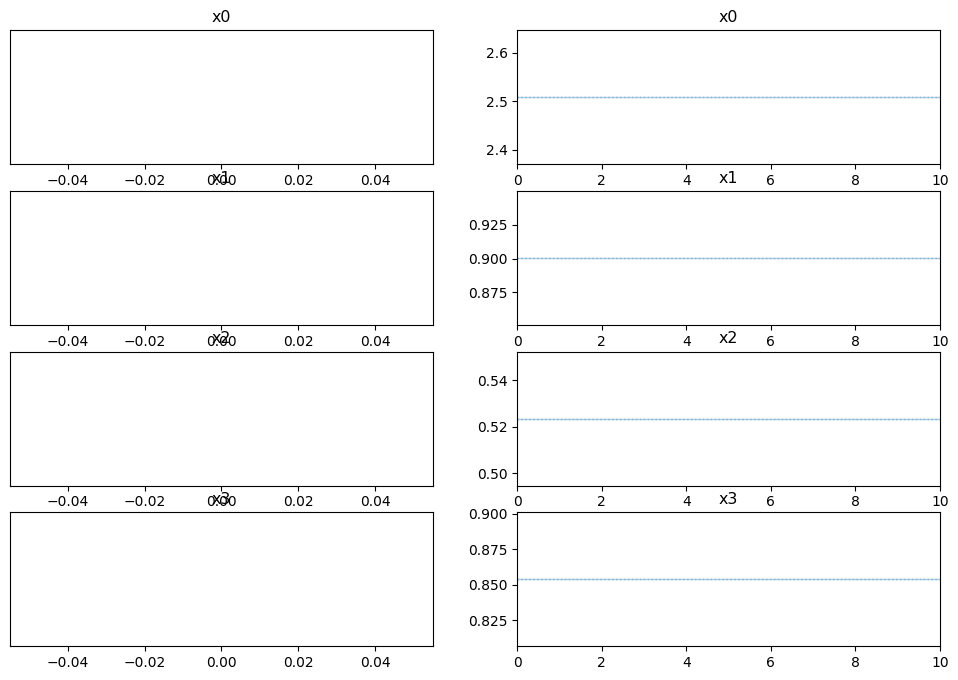

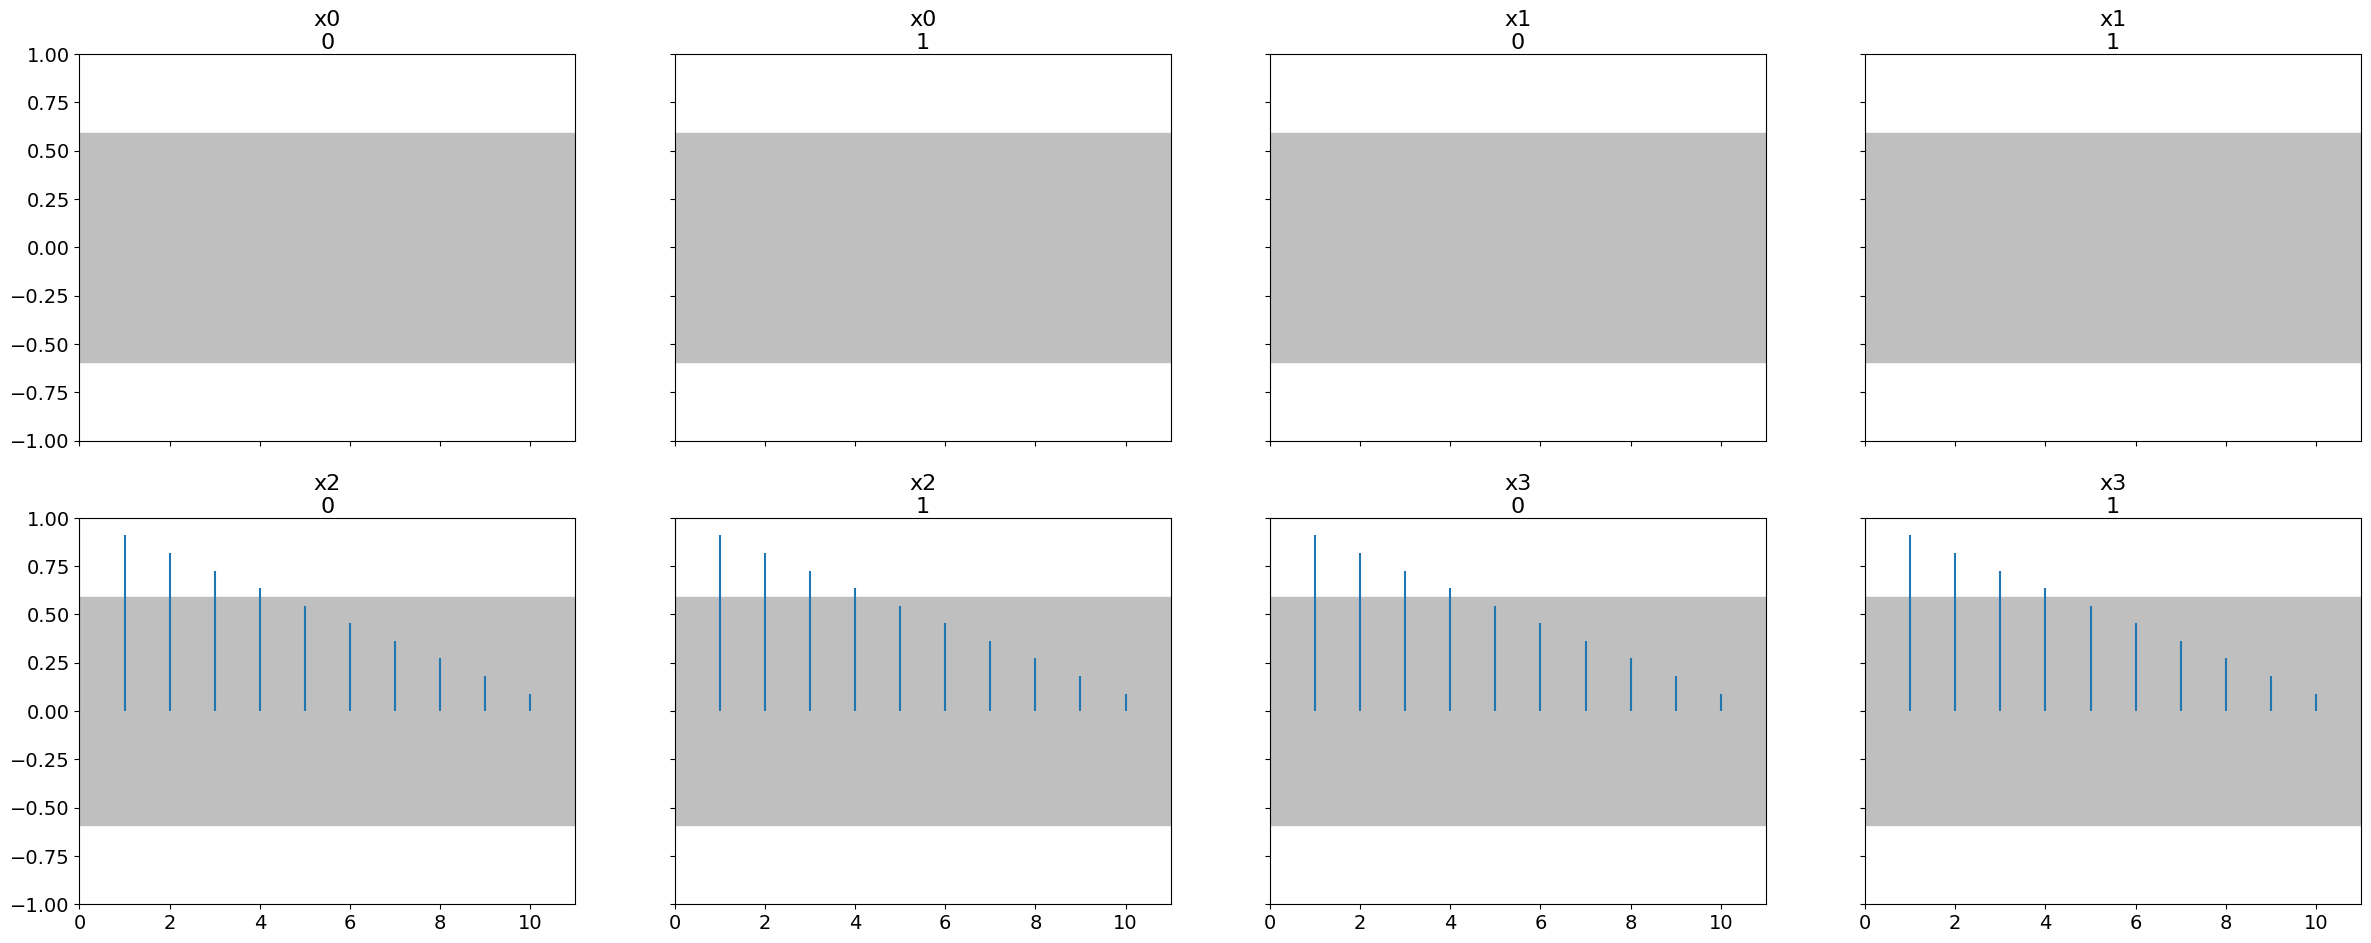

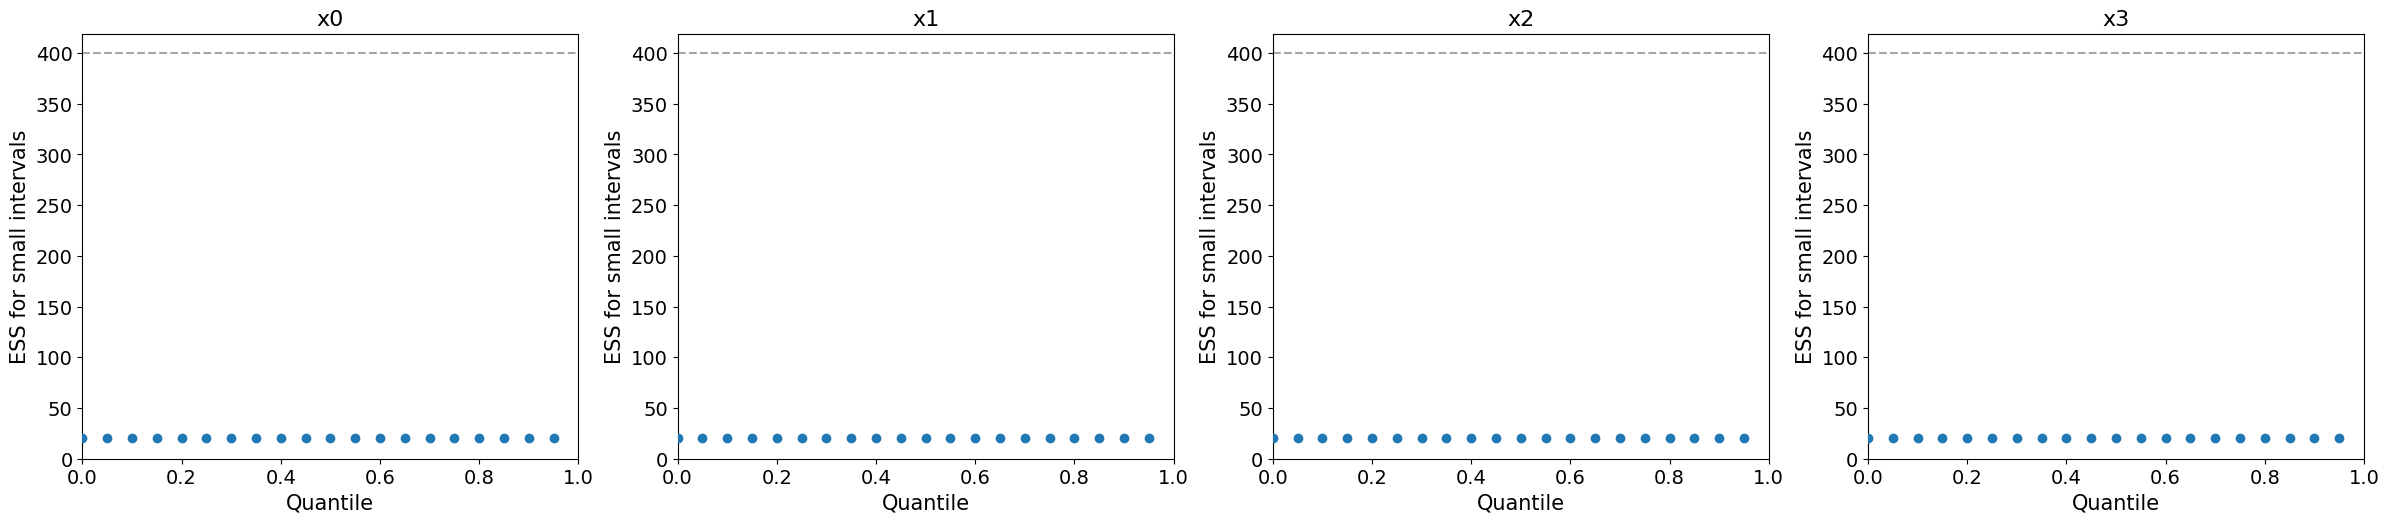

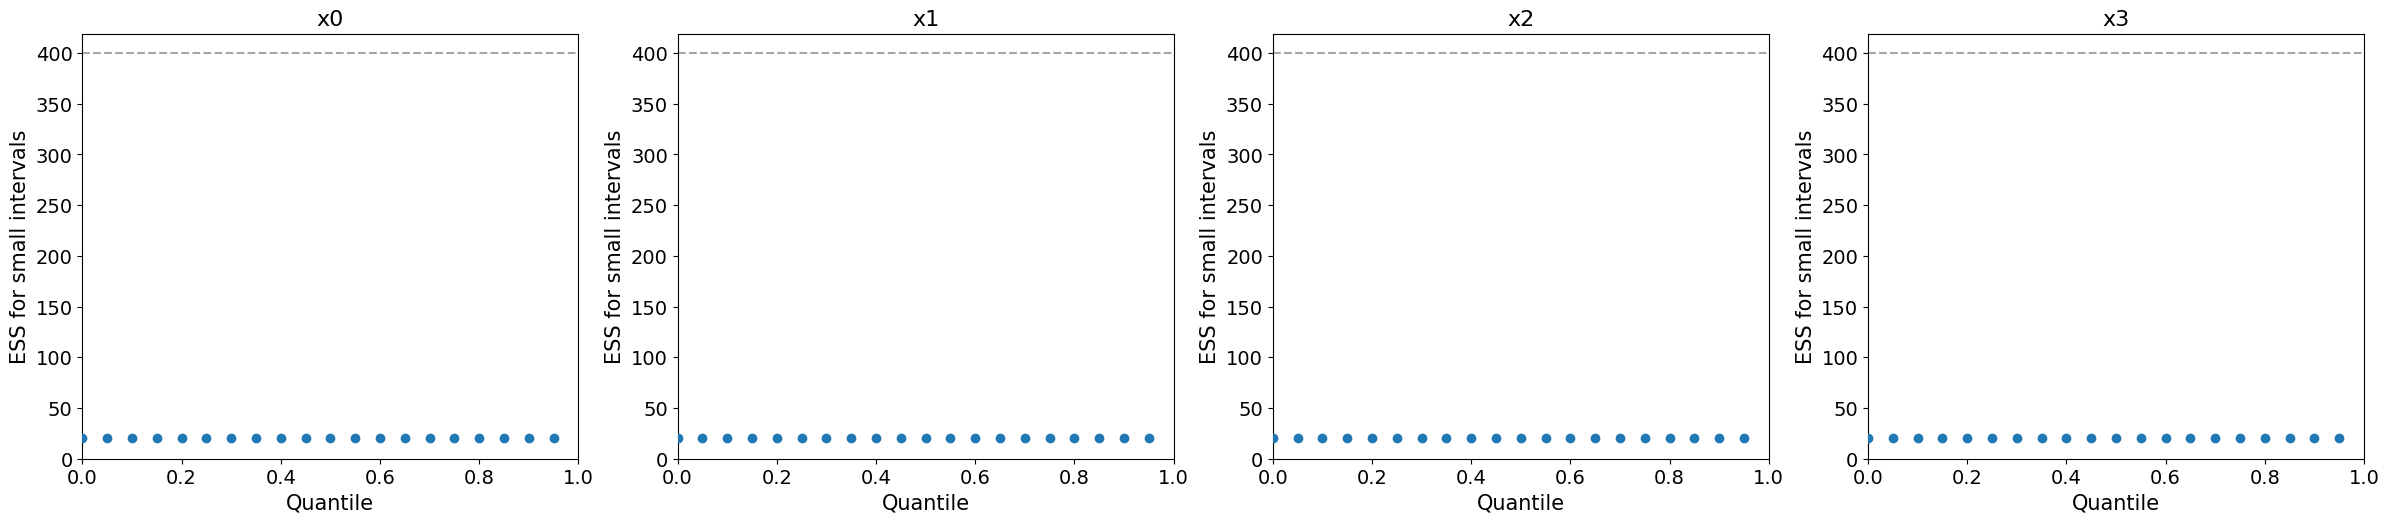

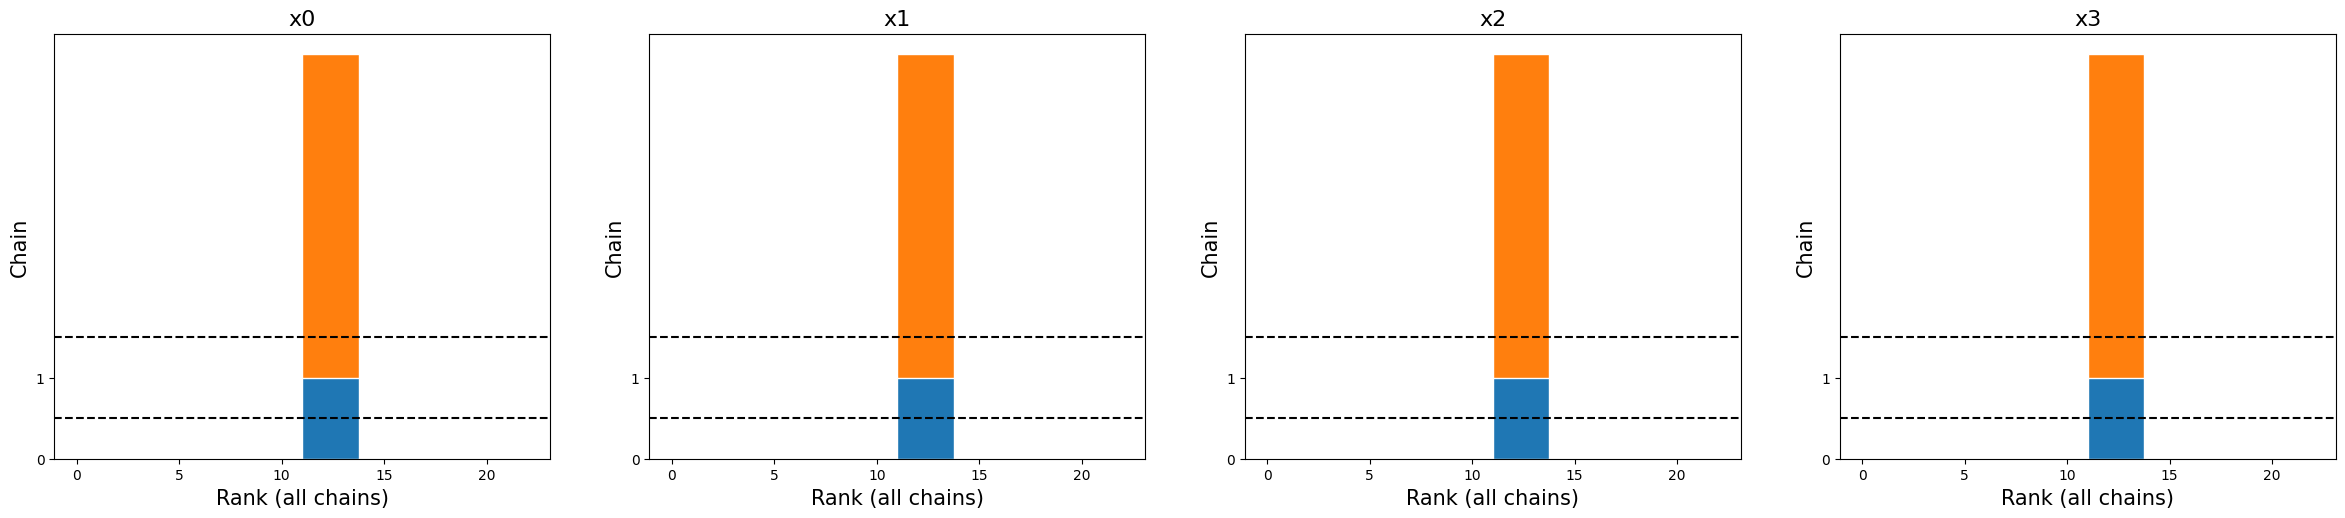

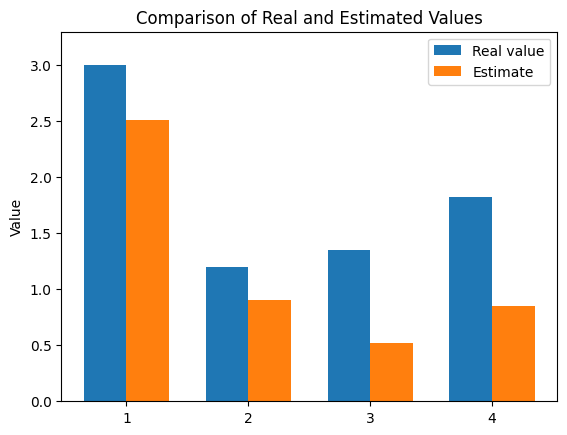

The function param_inverse took 68.561547 seconds.
Sampling 2 chains in parallel


2024-08-11 01:14:55,527	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


KeyboardInterrupt: 

In [21]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 30
burnin = 20
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)
